<a href="https://colab.research.google.com/github/azad17-safin/python-data-toolkit/blob/main/BME_Cell_Counting_Pipeline_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p data output
!wget -O data/sample_cells.jpg "https://raw.githubusercontent.com/Shenggan/BCCD_Dataset/master/BCCD/JPEGImages/BloodImage_00000.jpg"

--2026-10-02 18:24:00--  https://raw.githubusercontent.com/Shenggan/BCCD_Dataset/master/BCCD/JPEGImages/BloodImage_00000.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23302 (23K) [image/jpeg]
Saving to: ‘data/sample_cells.jpg’

data/sample_cells.j 100%[===================>]  22.76K  --.-KB/s    in 0.007s  

2026-10-02 18:24:00 (3.23 MB/s) - ‘data/sample_cells.jpg’ saved [23302/23302]



In [5]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

image_path = 'data/sample_cells.jpg'
image = cv2.imread(image_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

contours, _ = cv2.findContours(opening, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 50
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

print(f"Total Cells Detected: {len(valid_contours)}")

cell_data = []

for idx, cnt in enumerate(valid_contours, start=1):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    equivalent_diameter = 2 * np.sqrt(area / np.pi)

    cell_data.append({
        'Cell_ID': idx,
        'Area_Pixels': area,
        'Perimeter_Pixels': round(perimeter, 2),
        'Equivalent_Diameter': round(equivalent_diameter, 2)
    })


(x, y), radius = cv2.minEnclosingCircle(cnt)
center = (int(x), int(y))
radius = int(radius)

cv2.circle(output_image, center, radius, (0, 255, 0), 2)

cv2.putText(output_image, str(idx), (center[0] - 10, center[1] + 5),
            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

df = pd.DataFrame(cell_data)
df.to_csv('output/cell_measurements.csv', index=False)

print("\nFirst 5 Measured Cells:")
display(df.head())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_rgb)
axes[0].set_title('Original Microscopy Image')
axes[0].axis('off')

axes[1].imshow(opening, cmap='gray')
axes[1].set_title('Thresholded Binary Mask (Otsu)')
axes[1].axis('off')

axes[2].imshow(output_image)
axes[2].set_title(f'Detected Cells (Count: {len(valid_contours)})')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('output/detection_summary.png', dpi=300)
plt.show()


Total Cells Detected: 17


NameError: name 'output_image' is not defined

Total Cells Detected: 17


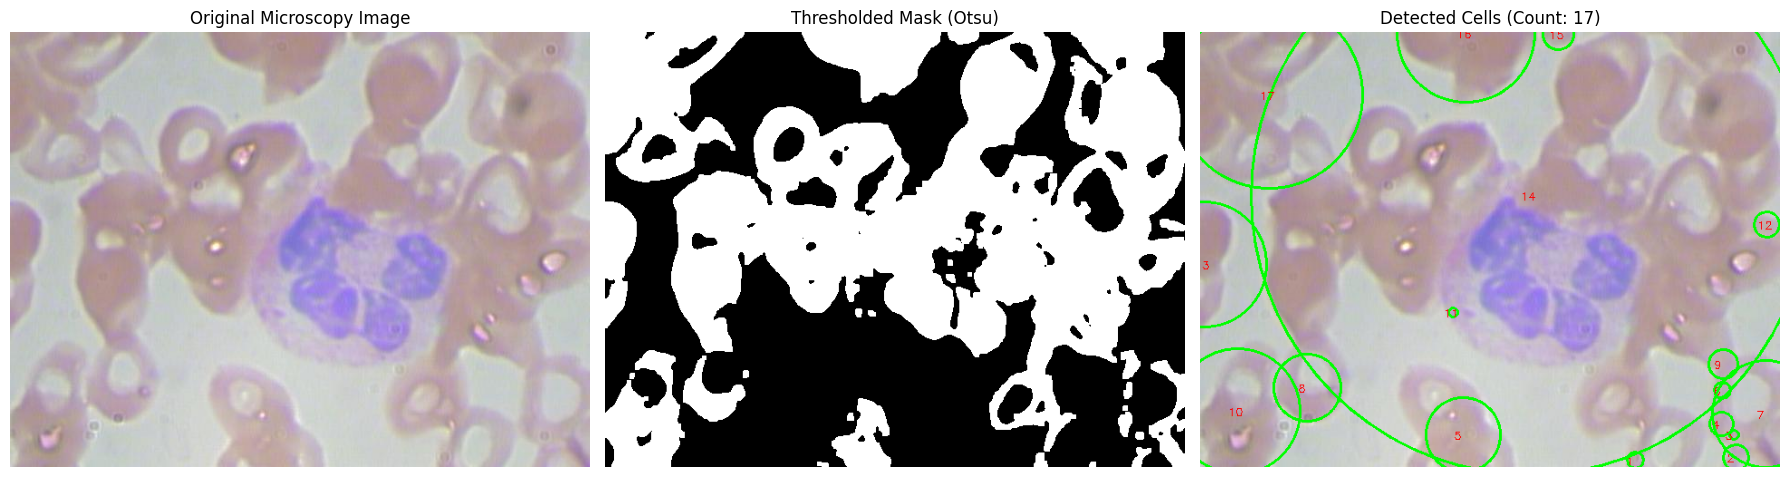

In [8]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

image_path='data/sample_cells.jpg'
image=cv2.imread(image_path)

image_rgb=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray=cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred=cv2.GaussianBlur(gray, (5, 5), 0)

_, thresh=cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel=np.ones((3, 3), np.uint8)
opening=cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

contours, _ =cv2.findContours(opening, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area=50
valid_contours=[c for c in contours if cv2.contourArea(c) > min_area]

print(f"Total Cells Detected: {len(valid_contours)}")

output_image=image_rgb.copy()
cell_data=[]

for idx, cnt in enumerate(valid_contours, start=1):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    (x, y), radius = cv2.minEnclosingCircle(cnt)
    center = (int(x), int(y))
    radius = int(radius)

    cv2.circle(output_image, center, radius, (0, 255, 0), 2)
    cv2.putText(output_image, str(idx), (center[0] - 10, center[1] + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

    cell_data.append({
        'Cell_ID': idx,
        'Area_Pixels': area,
        'Perimeter_Pixels': round(perimeter, 2),
        'Equivalent_Diameter': round(2 * np.sqrt(area / np.pi), 2)
    })

df = pd.DataFrame(cell_data)
os.makedirs('output', exist_ok=True)
df.to_csv('output/cell_measurements.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(image_rgb)
axes[0].set_title('Original Microscopy Image')
axes[0].axis('off')

axes[1].imshow(opening, cmap='gray')
axes[1].set_title('Thresholded Mask (Otsu)')
axes[1].axis('off')

axes[2].imshow(output_image)
axes[2].set_title(f'Detected Cells (Count: {len(valid_contours)})')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('output/detection_summary.png', dpi=300)
plt.show()